Simulations for advancement! 

Part 1) Simulations of Cold Started Horizontal Convection (no hills) with increasing Rayleigh number. 

In [1]:
using Oceananigans

In [2]:
using TopographicHorizontalConvection: HorizontalConvectionSimulation

In [5]:
simulation = HorizontalConvectionSimulation(Ra=1e7, h₀_frac=0.6, numhill = 1, Nx=535, Ny=1, Nz=67, b_init=-0.6, advection=true, architecture=CPU())

Simulation of NonhydrostaticModel{CPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
├── Next time step: 12.217 ms
├── Elapsed wall time: 0 seconds
├── Wall time per iteration: NaN days
├── Stop time: 52.705 minutes
├── Stop iteration : Inf
├── Wall time limit: Inf
├── Callbacks: OrderedDict with 6 entries:
│   ├── stop_time_exceeded => Callback of stop_time_exceeded on IterationInterval(1)
│   ├── stop_iteration_exceeded => Callback of stop_iteration_exceeded on IterationInterval(1)
│   ├── wall_time_limit_exceeded => Callback of wall_time_limit_exceeded on IterationInterval(1)
│   ├── nan_checker => Callback of NaNChecker for u on IterationInterval(100)
│   ├── wizard => Callback of TimeStepWizard(cfl=0.5, max_Δt=Inf, min_Δt=0.0) on IterationInterval(50)
│   └── progress => Callback of (::TopographicHorizontalConvection.var"#progress#9") on IterationInterval(10)
├── Output writers: OrderedDict with 6 entries:
│   ├── checkpointer => Checkpointer{TimeInterval, Vector{Symbol}}

In [6]:
run!(simulation, pickup=false)

┌ Info: Initializing simulation...
└ @ Oceananigans.Simulations /Users/hfdrake/.julia/packages/Oceananigans/thcPW/src/Simulations/run.jl:184


i:      0, sim time:  0.000, wall time:  0 seconds, Δt:  0.0134, advective CFL: 0.00e+00, diffusive CFL: 1.91e-02


┌ Info:     ... simulation initialization complete (2.339 seconds)
└ @ Oceananigans.Simulations /Users/hfdrake/.julia/packages/Oceananigans/thcPW/src/Simulations/run.jl:220
┌ Info: Executing initial time step...
└ @ Oceananigans.Simulations /Users/hfdrake/.julia/packages/Oceananigans/thcPW/src/Simulations/run.jl:117
┌ Info:     ... initial time step complete (2.864 seconds).
└ @ Oceananigans.Simulations /Users/hfdrake/.julia/packages/Oceananigans/thcPW/src/Simulations/run.jl:126


i:     10, sim time:  0.134, wall time: 7.190 seconds, Δt:  0.0134, advective CFL: 7.83e-05, diffusive CFL: 1.91e-02
i:     20, sim time:  0.269, wall time: 9.444 seconds, Δt:  0.0134, advective CFL: 2.01e-04, diffusive CFL: 1.91e-02
i:     30, sim time:  0.403, wall time: 11.840 seconds, Δt:  0.0134, advective CFL: 4.21e-04, diffusive CFL: 1.91e-02
i:     40, sim time:  0.538, wall time: 14.124 seconds, Δt:  0.0134, advective CFL: 6.98e-04, diffusive CFL: 1.91e-02
i:     50, sim time:  0.672, wall time: 16.584 seconds, Δt:  0.0148, advective CFL: 1.12e-03, diffusive CFL: 2.10e-02
i:     60, sim time:  0.820, wall time: 19.352 seconds, Δt:  0.0148, advective CFL: 1.57e-03, diffusive CFL: 2.10e-02
i:     70, sim time:  0.968, wall time: 21.633 seconds, Δt:  0.0148, advective CFL: 2.06e-03, diffusive CFL: 2.10e-02
i:     80, sim time:  1.103, wall time: 24.036 seconds, Δt:  0.0148, advective CFL: 2.54e-03, diffusive CFL: 2.10e-02
i:     90, sim time:  1.251, wall time: 26.255 seconds, Δt

Excessive output truncated after 524412 bytes.

InterruptException: InterruptException:

In [6]:
using NCDatasets
using CairoMakie
using Printf
using Oceananigans.Fields
using Oceananigans.AbstractOperations: volume
using NaNStatistics

No hills simulations of horizontal convection:: Ra = 1e5 to 1e7. 

Below is an animation of Ra=1e5 -- laminar

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e5.mp4" type "video/mp4">
</video>

In [7]:
using TopographicHorizontalConvection:ε_analysis
using TopographicHorizontalConvection:plot_ε_normalized

In [3]:
ds0_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra100000.0_coldstart_buoyancy.nc"));
ds0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra100000.0_coldstart_oceanostics.nc"));

In [4]:
ε_theory_0, ε_avg_0, ε_mean_0 = ε_analysis(ds0_o);

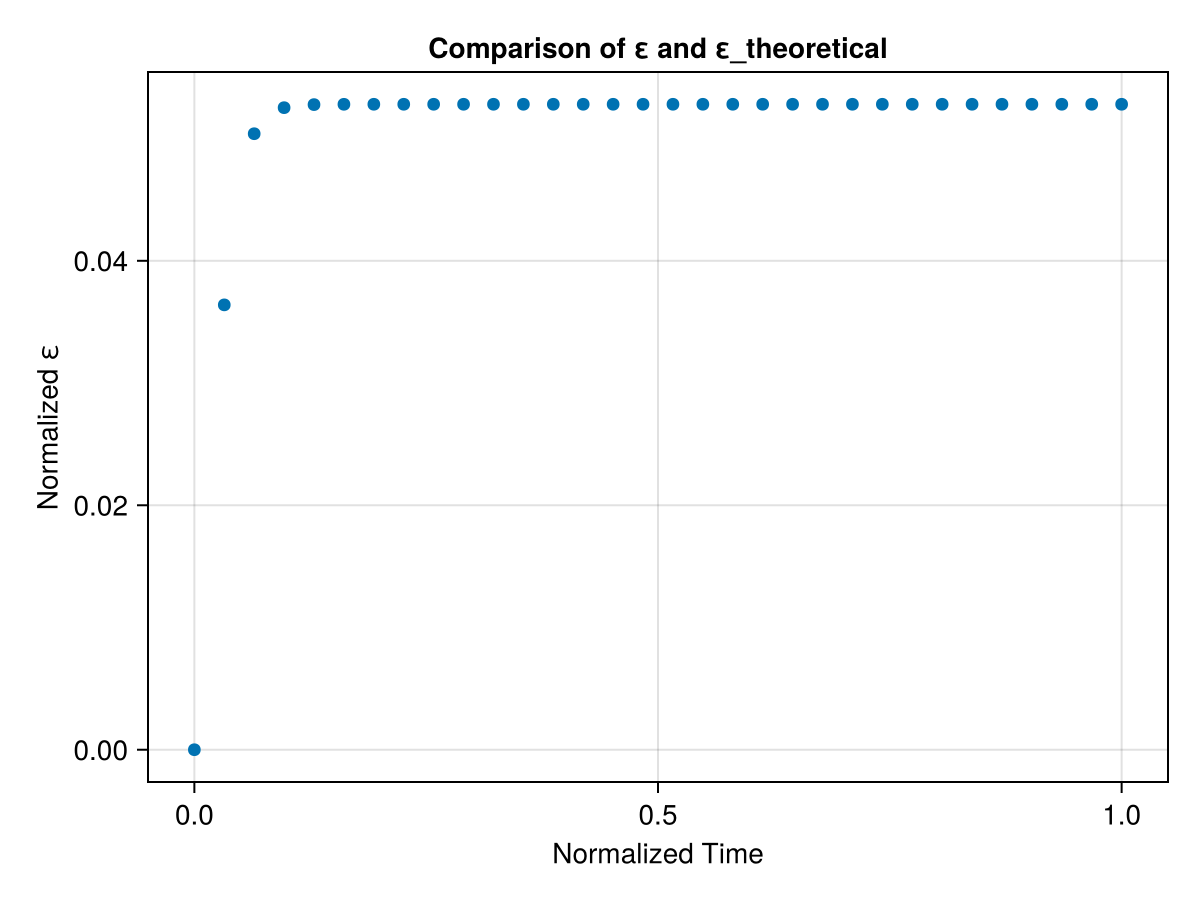

In [5]:
f0 = plot_ε_normalized(ds0_o)

In [6]:
ds1_b = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_buoyancy.nc"));
ds1_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_oceanostics.nc"));

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e6.mp4" type "video/mp4">
</video>

In [5]:
Ra = ds1_o.attrib["Ra"]
Pr = ds1_b.attrib["Pr"]
H = ds1_b.attrib["H"]
b★ = ds1_b.attrib["b★"]
κ = ds1_b.attrib["κ"]
ν = ds1_b.attrib["ν"]
Lx = ds1_b.attrib["Lx"]

8.0

In [7]:
ε_theory_1, ε_avg_1, ε_mean_1 = ε_analysis(ds1_o);

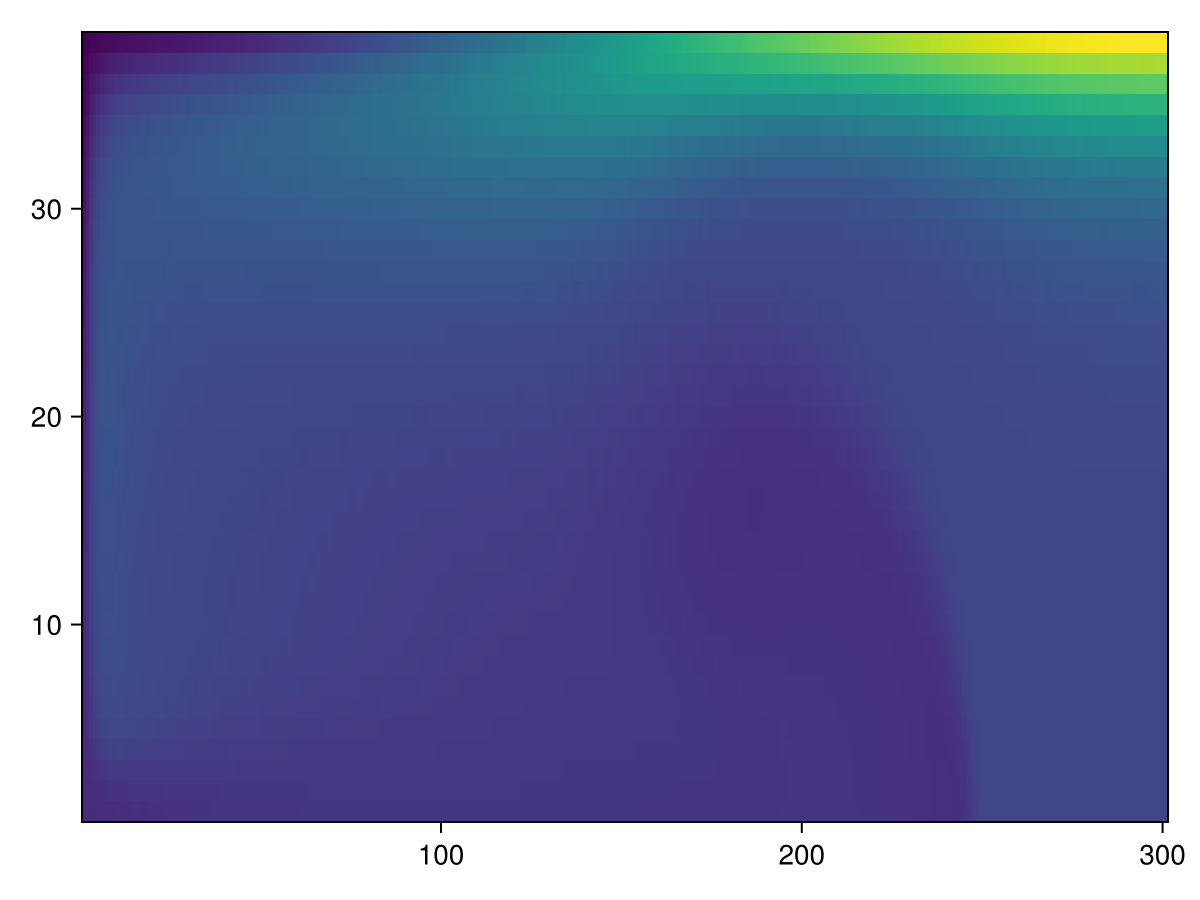

In [49]:
b = ds1_b["b"][4+1:end-4, :, 4+1:end-4, :];
time = ds1_b["time"][:];
size(time)

heatmap(b[:, 1, :, 10])

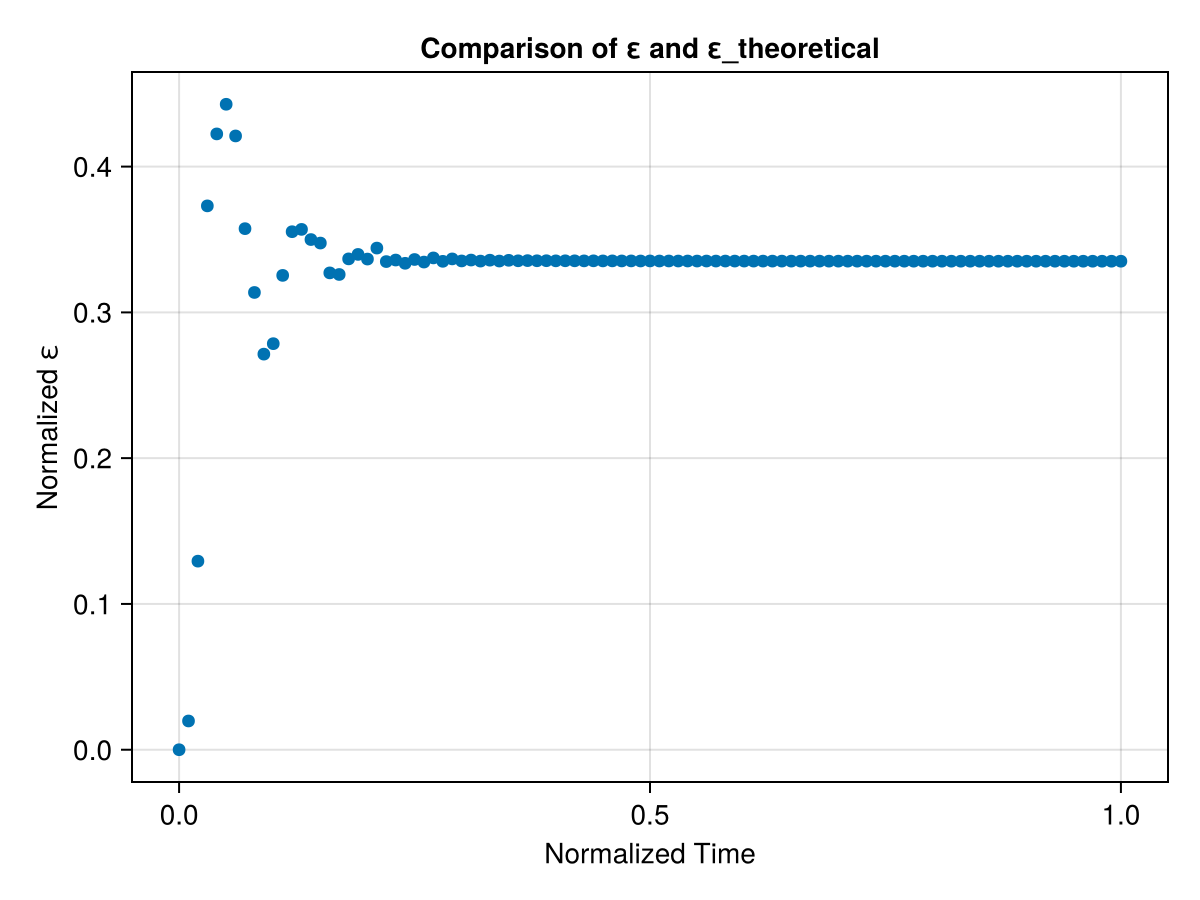

In [9]:
f1 = plot_ε_normalized(ds1_o)

In the second simulation we increase the Rayleigh number to 1e7
I didn't run this all the way to equilibrium $\tau_{eq} = \sqrt{1\times 10^{8}}$ because it took over 12 hours to just run up to $t=1830$ locally. 

In [10]:
ds2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra1.0e7_coldstart_oceanostics.nc"));
ds2_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra1.0e7_coldstart_buoyancy.nc"));

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e7.mp4" type "video/mp4">
</video>

In [11]:
ε_theory_2, ε_avg_2, ε_mean_2 = ε_analysis(ds2_o);

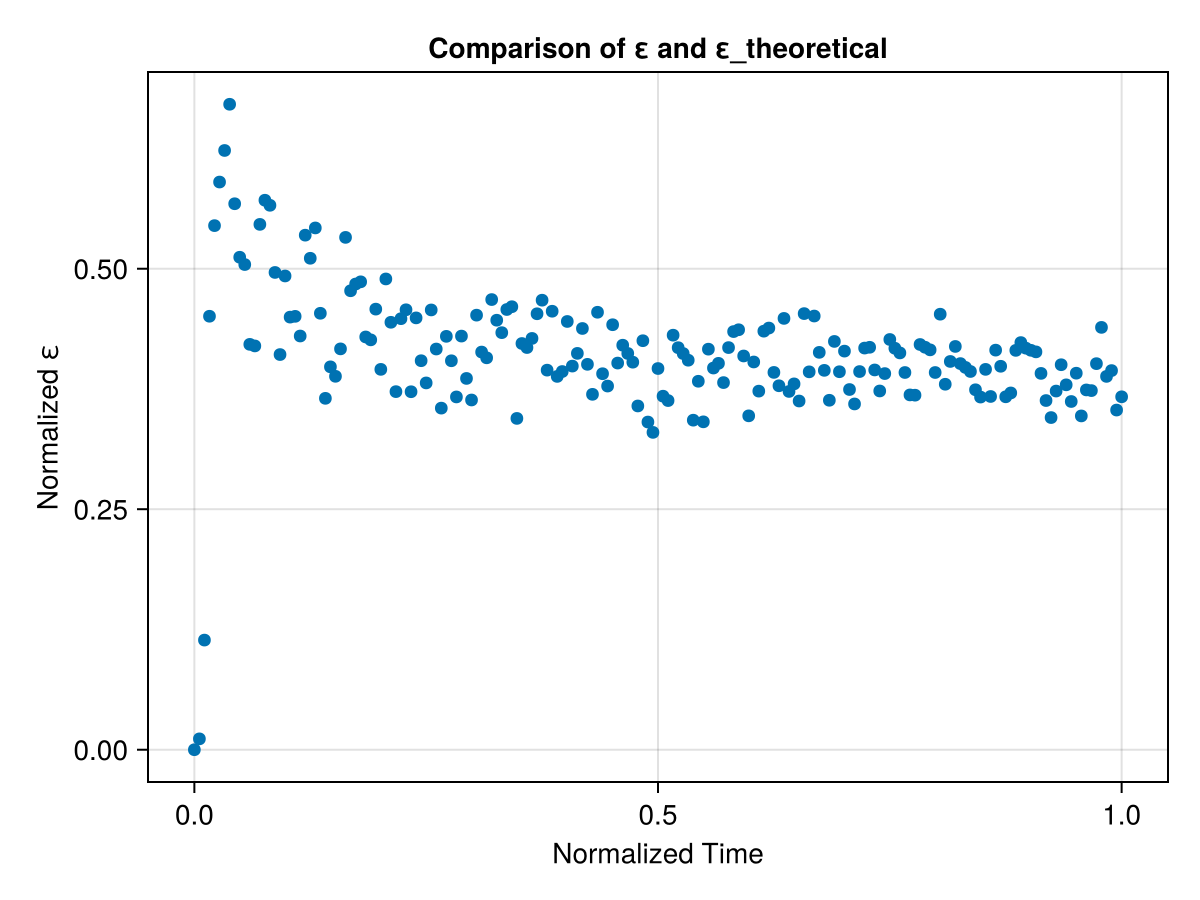

In [12]:
f2 = plot_ε_normalized(ds2_o)

In [18]:
equilibrium_start = round(Int, 0.9 * size(ε_avg_2, 1))
ε_avg_2_equilibrated = ε_avg_2[equilibrium_start:end]
ε_mean_2_equilibrated = nanmean(ε_avg_2_equilibrated)

#ε_theory_2

0.00024311562110555899

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills5e6.mp4" type "video/mp4">
</video>

In [8]:
ds3_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra5.0e6_coldstart_buoyancy.nc"));
ds3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra5.0e6_coldstart_oceanostics.nc"));

In [ ]:
ε_theory_3, ε_avg_3, ε_mean_3 = ε_analysis(ds3_o);

(196,)

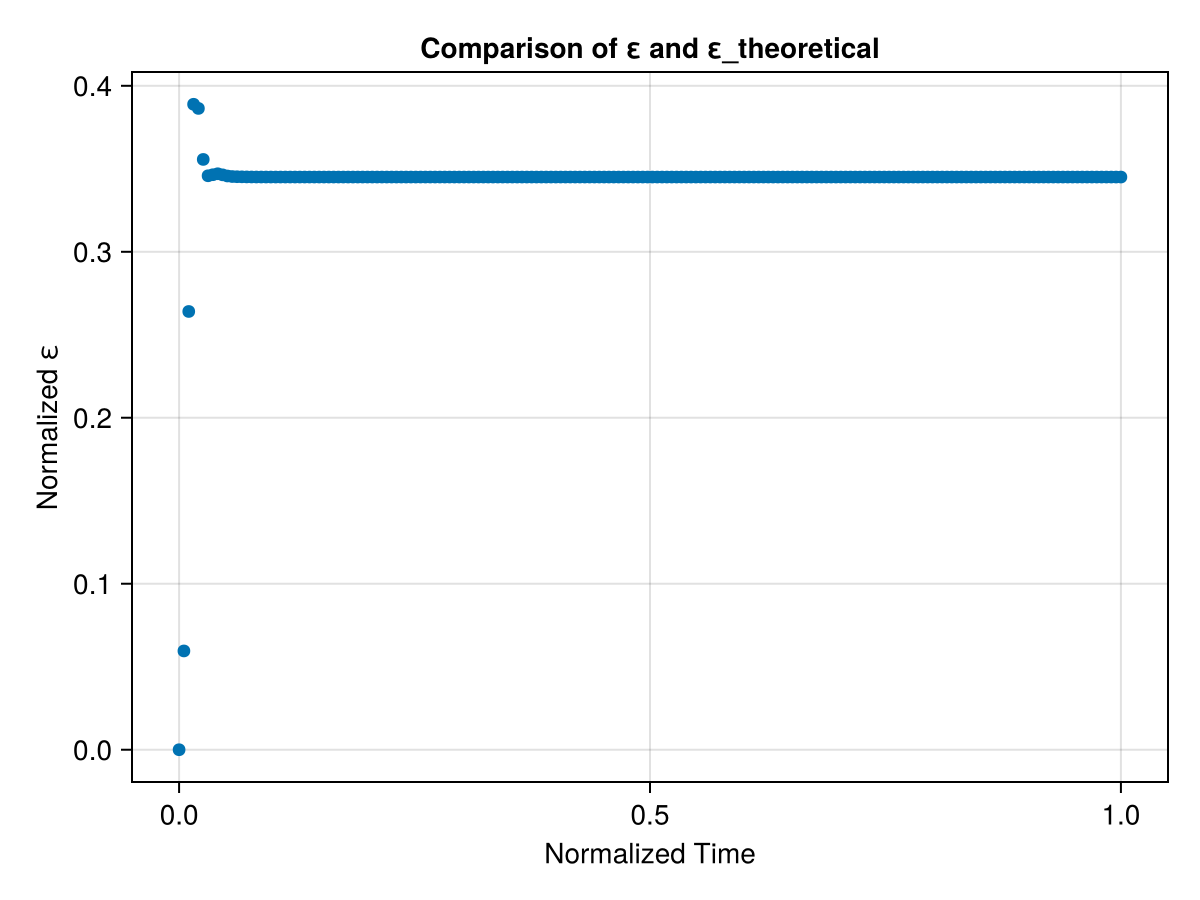

In [9]:
f3 = plot_ε_normalized(ds3_o)

f3

NOW for the hills simulations

below is Ra=1e6 with one hill

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e6.mp4" type "video/mp4">
</video>

In [7]:
ds_h1_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_buoyancy.nc"));
ds_h1_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_oceanostics.nc"));

UndefVarError: UndefVarError: `NCDataset` not defined